# OEMOF Step 3 — District Heating Optimization Model
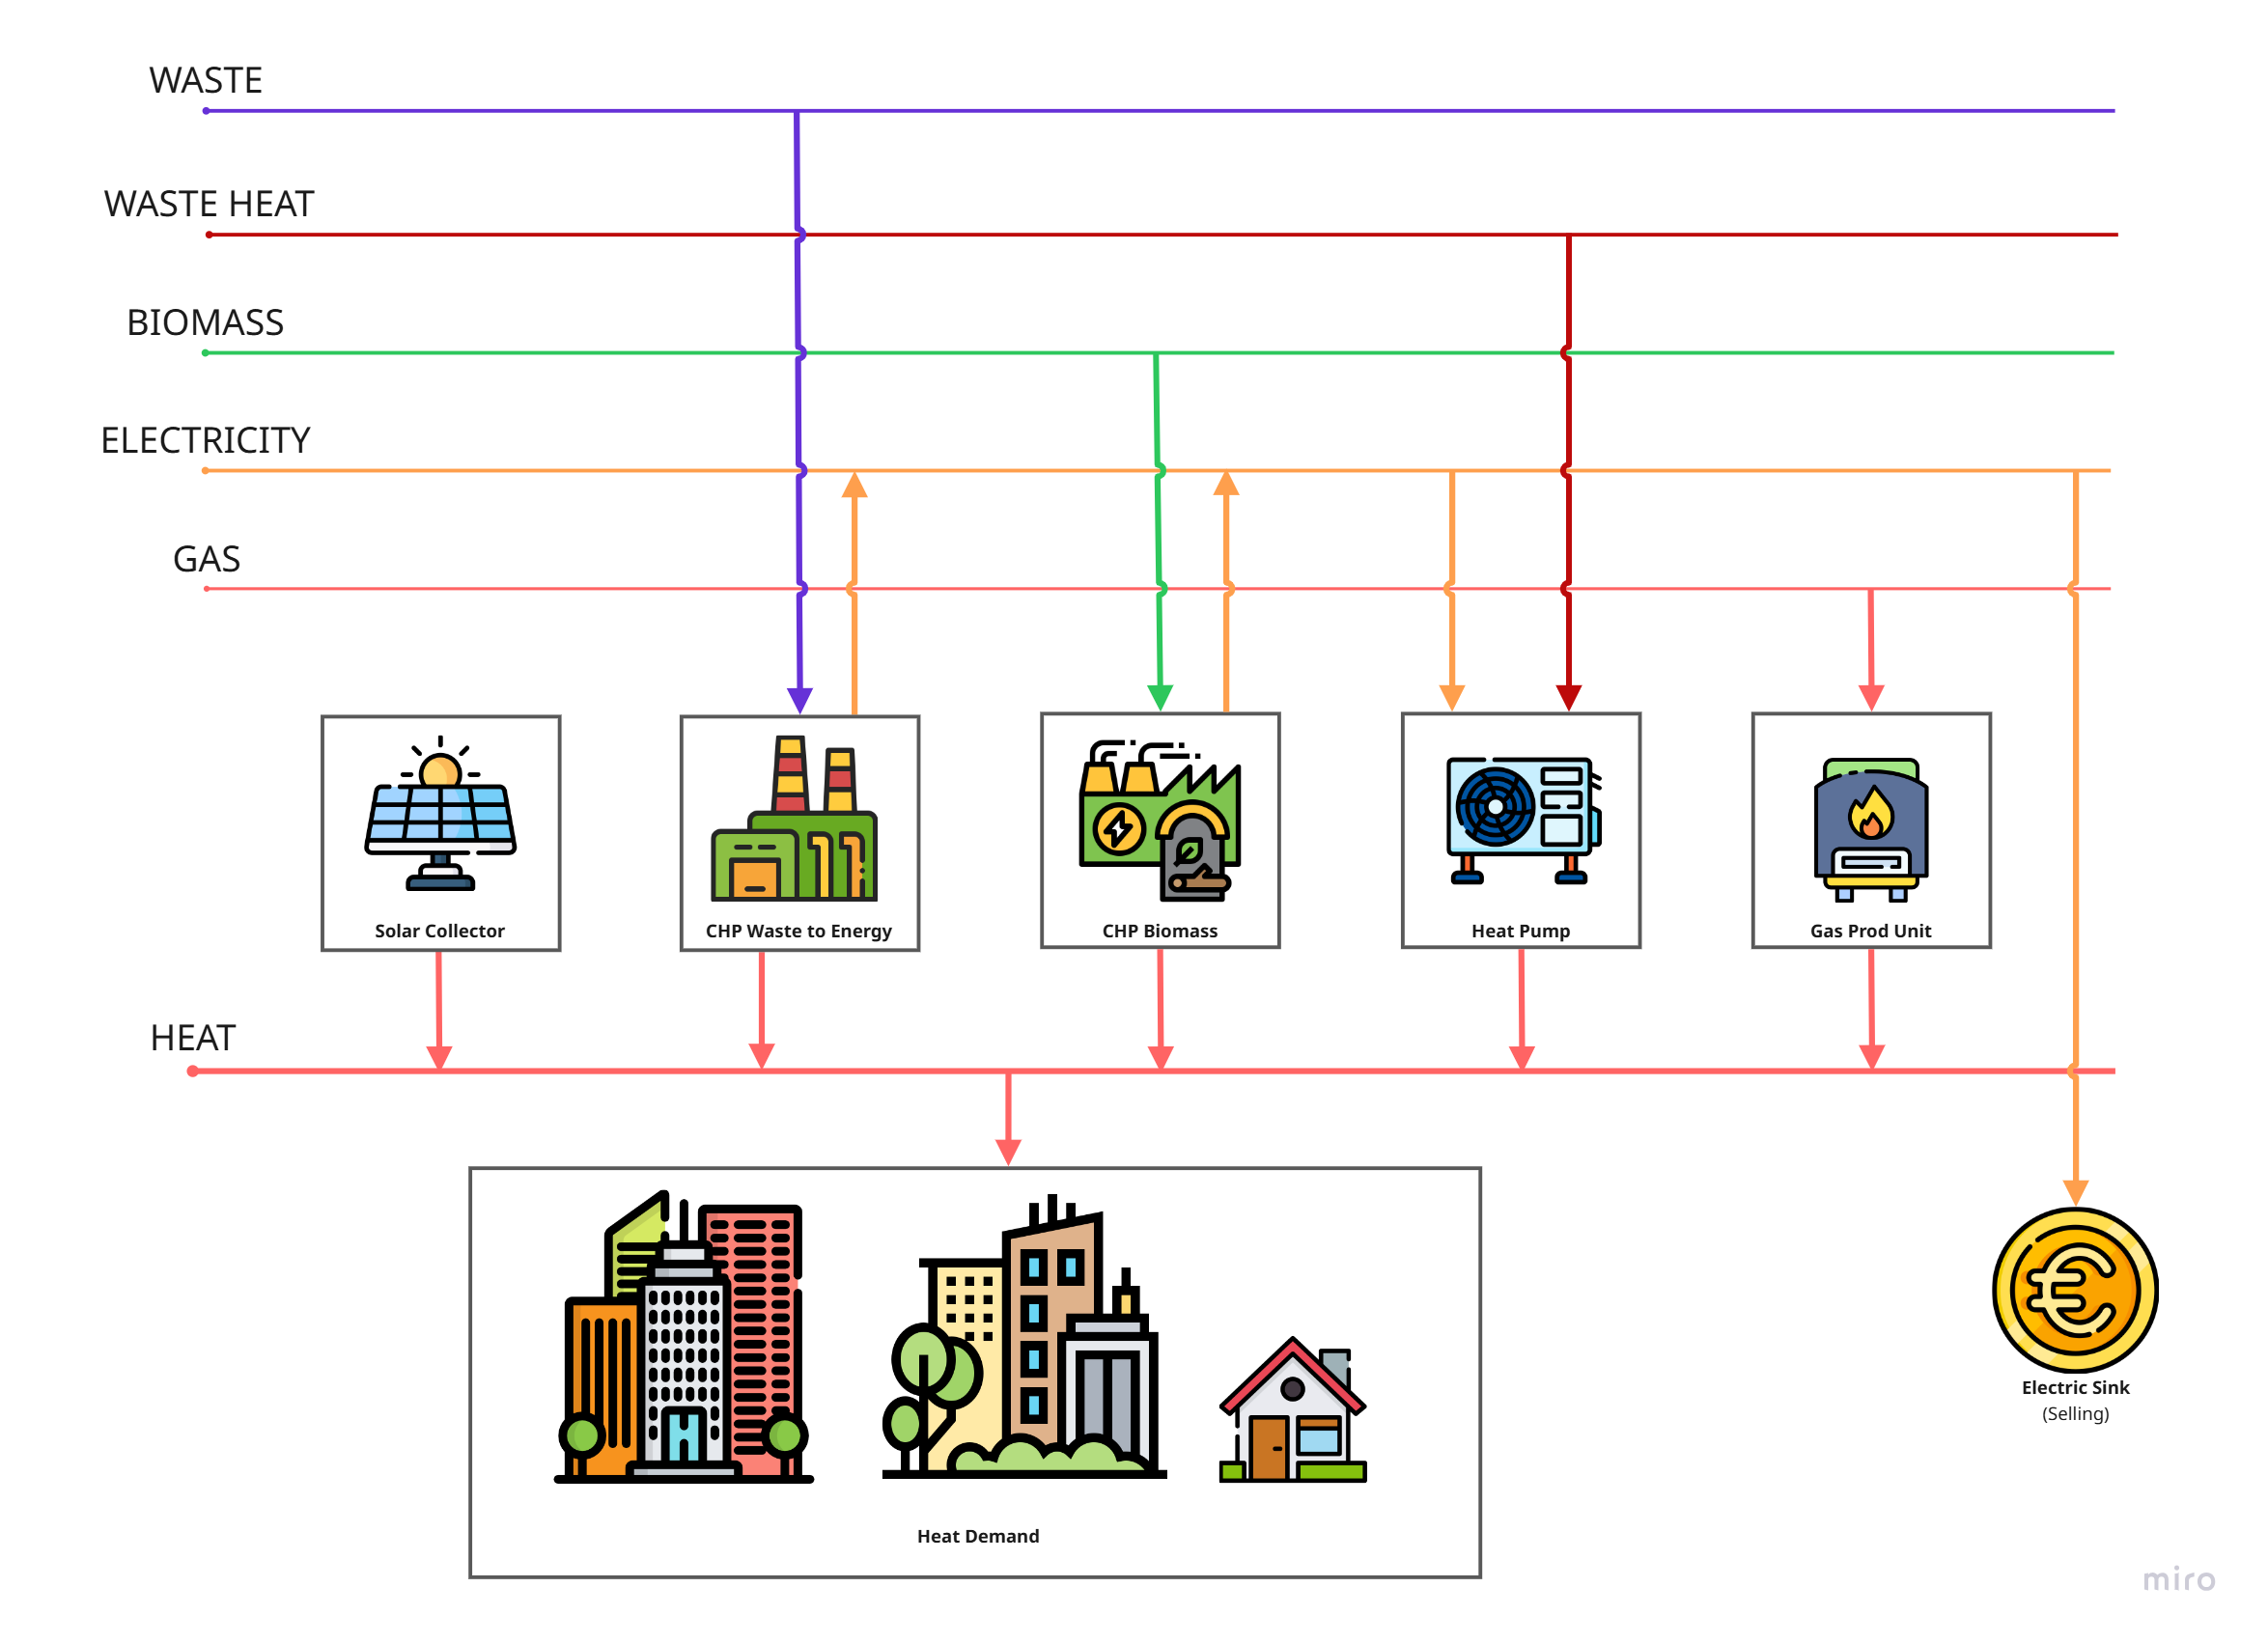

This notebook builds and solves an oemof.solph energy system model for a district heating network.

**Structure**
1. Imports  
2. Inputs & parameters  
3. Energy system (buses, sources, loads, powerplants)  
4. Optimize  
5. Results & export


## 1. Imports

In [21]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model,
                         create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph
import numpy as np




## 2. Inputs

Load your time series into a DataFrame named `data`.

Expected columns:
- `gas_price_Euro_Per_MWh`
- `electricity_price_Euro_Per_MWh`
- `biomass_Euro_Per_MWh`
- `waste_Euro_Per_MWh`
- `thermal_demand_MW`
- `irradiance_direct_MW/m2`
- `irradiance_diffuse_MW/m2`


In [22]:
filename = r"../2_inputs/3_OEMOF/input_data.csv"
data = pd.read_csv(filename)
solver = "gurobi"
solver_verbose = False

print(data.columns.tolist())


['thermal_demand_MW', 'electricity_price_Euro_Per_MWh', 'co2_price', 'gas_price_Euro_Per_MWh', 'biomass_Euro_Per_MWh', 'waste_Euro_Per_MWh', 'irradiance_direct_MW/m2', 'irradiance_diffuse_MW/m2']


### 2.1 Model sizing (fixed capacities)

All capacities are fixed inputs (no investment optimization in this step).


In [23]:
capacity_gas_heat = 3      # MW
capacity_biomass_chp = 5   # MW (fuel capacity as used in CHP input flow)
capacity_wte_chp = 5       # MW (fuel capacity as used in CHP input flow)
max_heat_hp = 3            # MW (thermal output limit)
area_m2 = 4000             # m2 (solar thermal collector area)


## 3. Energy System

### 3.0 Time index and EnergySystem

In [24]:
datetimeindex = create_time_index(2023, number=len(data))[:len(data)]
data.index = datetimeindex
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)


### 3.1 Buses

Buses represent energy carriers (electricity, heat, fuels, waste heat).


In [25]:
electrical_bus = Bus(label="electrical_bus")
thermal_bus    = Bus(label="thermal_bus")
gas_bus        = Bus(label="gas_bus")
biomass_bus    = Bus(label="biomass_bus")
waste_bus      = Bus(label="waste_bus")
wasteheat_bus  = Bus(label="wasteheat_bus")

energysystem.add(
    electrical_bus, thermal_bus, gas_bus,
    biomass_bus, waste_bus, wasteheat_bus
)

### 3.2 Sources

Sources inject energy into the system:
- fuels (gas, biomass, waste)
- electricity grid import
- exogenous waste heat (limited supply)


In [26]:
energysystem.add(
    Source(
        label="natural_gas",
        outputs={gas_bus: Flow(variable_costs=data["gas_price_Euro_Per_MWh"])},
    ),
    Source(
        label="electricity_grid",
        outputs={electrical_bus: Flow(variable_costs=data["electricity_price_Euro_Per_MWh"])},
    ),
    Source(
        label="biomass",
        outputs={biomass_bus: Flow(variable_costs=data["biomass_Euro_Per_MWh"])},
    ),
    Source(
        label="waste",
        outputs={waste_bus: Flow(variable_costs=data["waste_Euro_Per_MWh"])},
    ),
    Source(
        label="waste_heat",
        outputs={wasteheat_bus: Flow(variable_costs=12, nominal_value=0.7, max=1.0)}, #MW #Waste heat cost 12 Eur/MWh
    ),
)


### 3.3 Loads

- Heat demand is modeled as a fixed sink profile (normalized by peak).
- Electricity export is modeled as a sink with **negative variable cost** (revenue).


In [27]:
thermal_peak = float(data["thermal_demand_MW"].max())

energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={
            thermal_bus: Flow(
                nominal_value=thermal_peak,
                fix=data["thermal_demand_MW"] / thermal_peak,
            )
        },
    ),
    Sink(
        label="excess_electricity",
        inputs={
            electrical_bus: Flow(
                variable_costs=data["electricity_price_Euro_Per_MWh"] * -1
            )
        },
    ),
)


### 3.4 Powerplants

This section adds conversion technologies:
- 3.4.1 Gas boiler (Converter)
- 3.4.2 Biomass CHP (ExtractionTurbineCHP)
- 3.4.3 Waste-to-energy CHP (ExtractionTurbineCHP)
- 3.4.4 Heat pump (Converter) — COP formulation
- 3.4.5 Solar thermal (Source)


#### 3.4.1 Gas boiler (heat-only)

- Input: `gas_bus`
- Output: `thermal_bus`
- Efficiency: `efficiency_gas_heat`


In [28]:
# ------------------------------------------------------------------
# Gas boiler operational constraints (from datasheet)
# ------------------------------------------------------------------
efficiency_gas_heat = 0.93
min_load_gas = 0.10        # 10% minimum load
warm_start_h = 0.08       # hours (documented, not explicitly modeled)
cold_start_h = 0.30       # hours (documented, not explicitly modeled)

# With hourly time steps, any start occupies at least 1 timestep
min_uptime_steps = 1

# Variable O&M only (fixed O&M handled in post-processing)
vom_heat = 0.64            # €/MWh_th

# Annual fixed costs for gas boiler (for post-processing)
fixed_costs_gas = 1063.37*capacity_gas_heat  # €euro/year -If we want compute after postprocessing

energysystem.add(
    Converter(
        label="heat_gas",
        inputs={gas_bus: solph.Flow()},
        outputs={
            thermal_bus: solph.Flow(
                nominal_value=capacity_gas_heat,
                min=min_load_gas,
                variable_costs=vom_heat,
                nonconvex=solph.NonConvex(
                    minimum_uptime=min_uptime_steps,
                    initial_status=0,
                    startup_costs=cold_start_h * data["gas_price_Euro_Per_MWh"] * capacity_gas_heat,
                    shutdown_costs=0
                ),
            )
        },
        conversion_factors={thermal_bus: efficiency_gas_heat},
    )
)

print(
    f"Gas boiler constraints: "
    f"min load = {min_load_gas*100:.0f}%, "
    f"warm start = {warm_start_h} h, "
    f"cold start = {cold_start_h} h (documented)."
)


Gas boiler constraints: min load = 10%, warm start = 0.08 h, cold start = 0.3 h (documented).


#### 3.4.2 Biomass CHP (ExtractionTurbineCHP)

- Fuel input: `biomass_bus`
- Outputs: electricity + heat
- Condensing mode: electric efficiency specified via `conversion_factor_full_condensation`


In [ ]:
# -----------------------------
# Biomass CHP (capacity = 5 MW_fuel input)
# -----------------------------

# Efficiencies (datasheet-aligned)
efficiency_biomass_chp_elc = 0.14
efficiency_biomass_chp_th_rel = 0.97
efficiency_biomass_chp_th = (1 - efficiency_biomass_chp_elc) * efficiency_biomass_chp_th_rel

# Condensing-mode electric efficiency (proxy: nameplate)
eta_el_cond_bio = 0.15

# Variable O&M (datasheet)
vom_el_bio = 9.80   # €/MWh_el
vom_th_bio = 1.45   # €/MWh_th

# Annual fixed costs for biomas CHP (for post-processing)
fixed_costs_biomass = 42747.58*capacity_biomass_chp  # €euro/year -If we want compute after postprocessing

# Operational constraints (datasheet)
biomass_min_load = 0.20  # 20%

# Reasonable UC constraints for biomass CHP (hourly model)
biomass_min_uptime = 48
biomass_min_downtime = 24

# Availability (forced 3% + planned 3 weeks/year)
availability_bio = 1 - 0.03 - (3 / 52)

# Startup/shutdown costs (reasonable cycling penalty)
# Scale with implied MW_el at full load:
bio_p_el_full = capacity_biomass_chp * efficiency_biomass_chp_elc  # 0.56 MW_el
# bio_startup_cost = 5000.0 * bio_p_el_full     # €/MW_el/start * MW_el
# bio_shutdown_cost = 0.2 * bio_startup_cost
bio_startup_cost = 0.5 * capacity_biomass_chp * data["biomass_Euro_Per_MWh"] 
bio_shutdown_cost = 0.2 * capacity_biomass_chp * data["biomass_Euro_Per_MWh"]

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="chp_biomass",
        inputs={
            biomass_bus: Flow(
                nominal_value=capacity_biomass_chp,  # MW_fuel
                min=biomass_min_load,
                max=availability_bio,
                nonconvex=solph.NonConvex(
                    startup_costs=bio_startup_cost,
                    shutdown_costs=bio_shutdown_cost,
                    minimum_uptime=biomass_min_uptime,
                    minimum_downtime=biomass_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(variable_costs=vom_el_bio),
            thermal_bus: Flow(variable_costs=vom_th_bio),
        },
        conversion_factors={
            electrical_bus: efficiency_biomass_chp_elc,
            thermal_bus: efficiency_biomass_chp_th,
        },
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_bio,
        },
    )
)


print(
    f"Biomass CHP (fuel cap={capacity_biomass_chp:.2f} MW_fuel): "
    f"P_el_full≈{bio_p_el_full:.2f} MW_el, "
    f"P_th_full≈{capacity_biomass_chp*efficiency_biomass_chp_th:.2f} MW_th, "
    f"availability={availability_bio:.3f}"
)


Biomass CHP (fuel cap=5.00 MW_fuel): P_el_full≈0.70 MW_el, P_th_full≈4.17 MW_th, availability=0.912


#### 3.4.3 Waste-to-energy CHP (ExtractionTurbineCHP)

Same structure as biomass CHP but different efficiencies and costs.


In [30]:
# -----------------------------
# Waste-to-Energy CHP (capacity = 4 MW_fuel input)
# -----------------------------

# Efficiencies (datasheet, annual avg)
efficiency_wte_chp_elc = 0.22
efficiency_wte_chp_th_rel = 0.80
efficiency_wte_chp_th = (1 - efficiency_wte_chp_elc) * efficiency_wte_chp_th_rel  # 0.624

# Condensing-mode electric efficiency (proxy: nameplate 23%)
eta_el_cond_wte = 0.23

# Variable O&M (datasheet)
vom_el_wte = 27.0  # €/MWh_el
vom_th_wte = 6.3   # €/MWh_th

#Fixed costs for WtE CHP (for post-processing)
fixed_costs_wte = 94214.0 * capacity_wte_chp  # €euro/year -If we want compute after postprocessing

# Operational constraints (datasheet)
wte_min_load = 0.20  # 20%
warm_start_h = 0.5   # documented (not resolved hourly)
cold_start_h = 2.0   # documented (not resolved hourly)

# Reasonable UC constraints for WtE (baseload-ish operation)
wte_min_uptime = 48
wte_min_downtime = 24

# Availability (forced 1% + planned 3.01 weeks/year)
availability_wte = 1 - 0.01 - (3.01 / 52)

# Startup/shutdown costs (reasonable cycling penalty)
# Scale with implied MW_el at full load:
wte_p_el_full = capacity_wte_chp * efficiency_wte_chp_elc  # 0.88 MW_el
# wte_startup_cost = 8000.0 * wte_p_el_full   # €/MW_el/start * MW_el
# wte_shutdown_cost = 0.2 * wte_startup_cost
startup_hours = 2.0
startup_fuel_MWh = capacity_wte_chp * startup_hours  # MW_fuel * h = MWh_fuel
wte_startup_cost = startup_fuel_MWh * data["waste_Euro_Per_MWh"]  # €/start (time series)
wte_shutdown_cost = 0.2 * capacity_wte_chp * data["waste_Euro_Per_MWh"]

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="waste_to_energy",
        inputs={
            waste_bus: Flow(
                nominal_value=capacity_wte_chp,  # MW_fuel
                min=wte_min_load,
                max=availability_wte,
                nonconvex=solph.NonConvex(
                    startup_costs=wte_startup_cost,
                    shutdown_costs=wte_shutdown_cost,
                    minimum_uptime=wte_min_uptime,
                    minimum_downtime=wte_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(variable_costs=vom_el_wte),
            thermal_bus: Flow(variable_costs=vom_th_wte),
        },
        conversion_factors={
            electrical_bus: efficiency_wte_chp_elc,
            thermal_bus: efficiency_wte_chp_th,
        },
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_wte,
        },
    )
)

# energysystem.add(
#     solph.components.Converter(
#         label="wte_bypass",
#         inputs={
#             waste_bus: Flow(
#                 nominal_value=capacity_wte_chp,   # same fuel limit (or set its own)
#                 min=0,
#                 max=availability_wte,
#                 nonconvex=solph.NonConvex(),      # gives on/off status var if you need exclusivity
#             )
#         },
#         outputs={
#             thermal_bus: Flow(variable_costs=vom_th_wte),  # heat VOM for bypass
#         },
#         conversion_factors={
#             thermal_bus: efficiency_wte_chp_th_rel,  # using relative thermal efficiency
#         },
#     )
# )

print(
    f"WtE CHP (fuel cap={capacity_wte_chp:.2f} MW_fuel): "
    f"P_el_full≈{wte_p_el_full:.2f} MW_el, "
    f"P_th_full≈{capacity_wte_chp*efficiency_wte_chp_th:.2f} MW_th, "
    f"availability={availability_wte:.3f}, "
    f"warm/cold start={warm_start_h}/{cold_start_h} h (documented)"
)
print(wte_startup_cost)



WtE CHP (fuel cap=5.00 MW_fuel): P_el_full≈1.10 MW_el, P_th_full≈3.12 MW_th, availability=0.932, warm/cold start=0.5/2.0 h (documented)
2023-01-01 00:00:00    246.0
2023-01-01 01:00:00    246.0
2023-01-01 02:00:00    246.0
2023-01-01 03:00:00    246.0
2023-01-01 04:00:00    246.0
                       ...  
2023-12-31 19:00:00    246.0
2023-12-31 20:00:00    246.0
2023-12-31 21:00:00    246.0
2023-12-31 22:00:00    246.0
2023-12-31 23:00:00    246.0
Freq: h, Name: waste_Euro_Per_MWh, Length: 8760, dtype: float64


#### 3.4.4 Heat pump (Converter)

Energy balance per 1 MWh_th output:
- Electricity input: **1/COP**
- Source heat input: **(COP−1)/COP**


In [31]:
# -----------------------------
# Heat pump (datasheet-aligned)
# -----------------------------

# Capacity
hp_min_load = 0.25         # 25% minimum load

# COP from datasheet: 430% = 4.30
cop_hp = 4.30

# Costs
vom_hp_th = 2.86           # €/MWh_th (variable O&M total)
startup_cost_per_mw = 10.63  # €/MW_th per startup
fixed_costs_hp = 2126.75 * max_heat_hp  # €euro/year -If we want compute after postprocessing

# Convert startup cost to €/startup for your installed size
# hp_startup_cost = startup_cost_per_mw * max_heat_hp
# hp_shutdown_cost = 0.2 * hp_startup_cost  # reasonable assumption
hp_startup_cost = 1 * max_heat_hp * data["electricity_price_Euro_Per_MWh"]
hp_shutdown_cost = 0.2 * max_heat_hp * data["electricity_price_Euro_Per_MWh"]

# Availability (planned outage 1 week/year, forced outage 0%)
availability_hp = 1 - (1 / 52)

energysystem.add(
    solph.components.Converter(
        label="heat_pump",
        inputs={
            electrical_bus: Flow(),
            wasteheat_bus: Flow(),
        },
        outputs={
            thermal_bus: Flow(
                nominal_value=max_heat_hp,
                min=hp_min_load,
                max=availability_hp,
                variable_costs=vom_hp_th,
                nonconvex=solph.NonConvex(
                    startup_costs=hp_startup_cost,
                    shutdown_costs=hp_shutdown_cost,
                    # optional (keep simple unless you really need it):
                    minimum_uptime=1,
                    minimum_downtime=1,
                    initial_status=0,
                ),
            ),
        },
        conversion_factors={
            electrical_bus: 1 / cop_hp,
            wasteheat_bus: (cop_hp - 1) / cop_hp,
        },
    )
)

# print(
#     f"HP aligned: COP={cop_hp}, min load={hp_min_load*100:.0f}%, "
#     f"availability={availability_hp:.3f}, startup cost={hp_startup_cost:.2f} €/start"
# )
print(hp_startup_cost)

2023-01-01 00:00:00    88.68
2023-01-01 01:00:00    85.38
2023-01-01 02:00:00    79.98
2023-01-01 03:00:00    73.44
2023-01-01 04:00:00    72.03
                       ...  
2023-12-31 19:00:00    62.94
2023-12-31 20:00:00    50.73
2023-12-31 21:00:00    49.62
2023-12-31 22:00:00    46.95
2023-12-31 23:00:00     6.45
Freq: h, Name: electricity_price_Euro_Per_MWh, Length: 8760, dtype: float64


#### 3.4.5 Solar thermal (Source)

Compute an hourly thermal output profile from irradiance and scale it by area.
Model it as a heat Source with:
- `nominal_value = peak output`
- `max = per-unit profile`


In [32]:
##Calculation of solar thermal input profile
tilt_deg = 45
eta = 0.48
annual_input = 1.05
pump_fraction = 0.01

dni = data["irradiance_direct_MW/m2"].clip(lower=0)
dhi = data["irradiance_diffuse_MW/m2"].clip(lower=0)
cosZ = 0.3
ghi = dhi + dni * cosZ

tilt = np.deg2rad(tilt_deg)
Rb = 1.0

G_tilt = (
    dni * Rb +
    dhi * (1 + np.cos(tilt)) / 2 +
    ghi * 0.2 * (1 - np.cos(tilt)) / 2
).clip(lower=0)

G_MWh = G_tilt / 1e6
scale = annual_input / G_MWh.sum()
G_input = G_MWh * scale
G_output = G_input * eta

solar_thermal_MW = G_output * area_m2
pump_MW = pump_fraction * solar_thermal_MW

Q_nominal = float(solar_thermal_MW.max())
solar_profile_pu = (solar_thermal_MW / Q_nominal).values

print("Solar thermal peak (MW):", Q_nominal)
print("Annual thermal output (MWh):", float(solar_thermal_MW.sum()))

# Variable O&M (from table)
vom_solar_th = 0.14887218  # €/MWh_th (from table)
annual_fixed_om_solar = 60.2719657 * Q_nominal  # €/MW_th/year (from table)

print("Solar thermal fixed O&M (documentation only):")
print(f"Installed capacity (Q_nominal): {Q_nominal:.3f} MW_th")
print(f"Annual fixed O&M cost: {annual_fixed_om_solar:.2f} €/year")


energysystem.add(
    Source(
        label="solar_thermal",
        outputs={
            thermal_bus: Flow(
                nominal_value=Q_nominal,      # MW_th
                max=solar_profile_pu,          # availability profile
                variable_costs=vom_solar_th,
            )
        },
    )
)



Solar thermal peak (MW): 1.68767712986937
Annual thermal output (MWh): 2015.9999999999998
Solar thermal fixed O&M (documentation only):
Installed capacity (Q_nominal): 1.688 MW_th
Annual fixed O&M cost: 101.72 €/year


In [33]:
demand_peak = float(data["thermal_demand_MW"].max())
print("Demand peak MW_th:", demand_peak)

# Upper bounds (rough, optimistic)
gas_max = capacity_gas_heat
hp_max = max_heat_hp
bio_max_th = capacity_biomass_chp * ((1-0.14)*0.97)   # if MW_fuel input
wte_max_th = capacity_wte_chp * ((1-0.22)*0.80)       # if MW_fuel input
print("Approx max heat MW_th (no solar):", gas_max + hp_max + bio_max_th + wte_max_th)


Demand peak MW_th: 9.26270011
Approx max heat MW_th (no solar): 13.291


## 4. Optimize

Solve the model using your solver (default: gurobi).

In [34]:
model = Model(energysystem, name="District Heating Optimization Model")
logging.info("Solving the optimization problem.")

model.solve(
    solver="gurobi",
    solve_kwargs={"tee": True},
    # If you don't have gurobi, try: solver="cbc"
)


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\solph\_plumbing.py:82: FutureWarning: Sequence longer than needed (8760 items instead of 8759). This will be trated as an error in the future.
  warnings.warn(
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmppkp5i1dc.pyomo.lp
Reading time = 1.27 seconds
x1: 350152 rows, 297709 columns, 2030278 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 350152 rows, 297709 columns and 2030278 nonzeros
Model fingerprint: 0x6e7385c8
Variable types: 192698 continuous, 105011 integer (105011 binary)
Coefficient statistics:
  Matrix range     [7e-02, 5e+01]
  Objective range  [6e-03, 2e+03]
  Bounds range     [1e-03, 5e+00]
  RHS range        [1e+00, 2e+01]
Presolve removed 213722 rows and 177241 columns
Presolve time: 4.27s
Presolved: 136430 rows, 120468 columns, 1328904 nonzeros
Variable type

{'Problem': [{'Name': 'x1', 'Lower bound': 957710.9887634733, 'Upper bound': 957794.4741388318, 'Number of objectives': 1, 'Number of constraints': 350152, 'Number of variables': 297709, 'Number of binary variables': 105011, 'Number of integer variables': 105011, 'Number of continuous variables': 192698, 'Number of nonzeros': 2030278, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Return code': '0', 'Message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Wall time': '60.02800011634827', 'Error rc': 0, 'Time': 62.47691869735718}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

## 5. Results & Export

In [35]:
energysystem.results["main"] = processing.results(model, remove_last_time_point=True)
energysystem.results["meta"] = processing.meta_results(model)

results = energysystem.results["main"]

output_file = os.path.join(os.getcwd(), "../3_outputs/OEMOF_step3_results.xlsx")
energysystem.dump(os.getcwd(), "../3_outputs/OEMOF_step3_results.xlsx")
logging.info("Results have been dumped.")

# Quick peek (optional)
# print(list(results.keys())[:5])


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


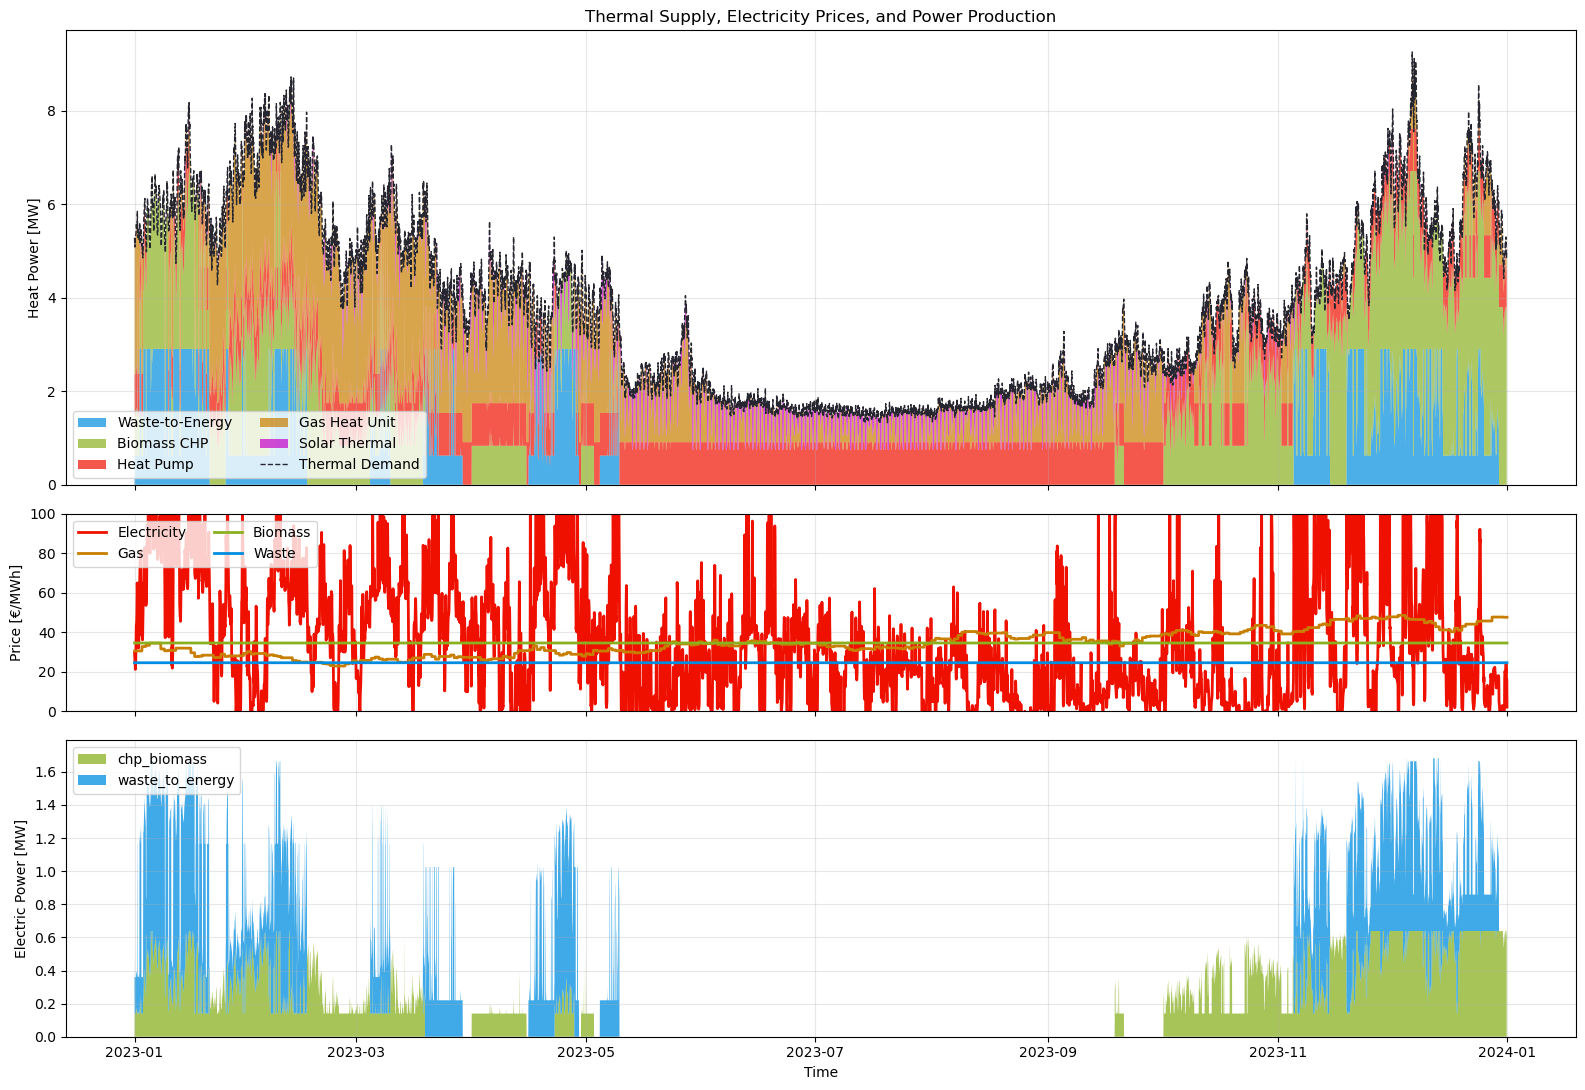

Electricity producers plotted: ['chp_biomass', 'waste_to_energy']


In [36]:
from plot_dispatch_and_prices import plot_dispatch_and_prices

plot_dispatch_and_prices(
    results=results,
    data=data,
    start="2023-01-01",
    end="2023-12-31",
)


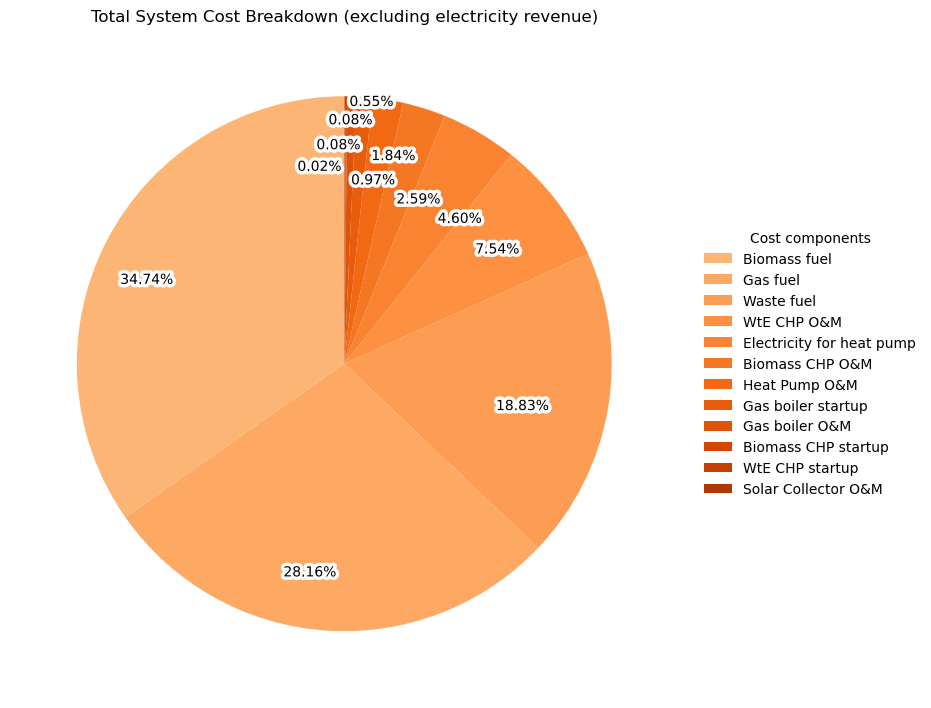

In [37]:
from om_cost_report import build_cost_df_and_plot_pie
from oemof.solph import views

dt = 1.0

el_bus_view = views.node(results, "electrical_bus")["sequences"]

el_revenue = (
    el_bus_view[(("electrical_bus", "excess_electricity"), "flow")]
    .dropna()
    .mul(dt)
    .mul(data["electricity_price_Euro_Per_MWh"])
    .sum()
)
cost_df, cost_df_pie = build_cost_df_and_plot_pie(
    results=results,
    data=data,

    capacity_gas_heat=capacity_gas_heat,
    capacity_biomass_chp=capacity_biomass_chp,
    capacity_wte_chp=capacity_wte_chp,
    max_heat_hp=max_heat_hp,

    vom_el_wte=vom_el_wte,
    vom_th_wte=vom_th_wte,
    vom_heat=vom_heat,
    vom_el_bio=vom_el_bio,
    vom_th_bio=vom_th_bio,
    vom_hp_th=vom_hp_th,
    vom_solar_th=vom_solar_th,

    el_revenue=el_revenue,

    save_csv="../3_outputs/Step3_O_M_cost_breakdown.csv",
    save_fig="../3_outputs/Step3_O_M_cost_breakdown_pie.png",
)


In [38]:
import numpy as np
import pandas as pd
from oemof.solph import views

eps = 1e-6  # adjust if you want a bigger threshold

# Get sequences for the component
wte_view = views.node(results, "waste_to_energy")["sequences"].iloc[:-1]

# Flows (adjust labels if your buses are named differently)
Pel = wte_view[(("waste_to_energy", "electrical_bus"), "flow")].astype(float)
Qth = wte_view[(("waste_to_energy", "thermal_bus"), "flow")].astype(float)

# Mode classification
mode = np.where(
    (Pel <= eps) & (Qth <= eps), "OFF",
    np.where(Qth > eps, "CHP/EXTRACTION", "FULL-CONDENSING")
)

df_mode = pd.DataFrame({
    "Pel": Pel,
    "Qth": Qth,
    "mode": mode,
})

# Hours in each mode (works if timestep is hourly; otherwise multiply by dt)
hours_by_mode = df_mode["mode"].value_counts().rename("hours").to_frame()

# Energy by mode (if hourly, MWh = MW * 1h; if dt != 1h, multiply by dt)
dt = 1.0  # set your timestep length in hours
energy_by_mode = df_mode.groupby("mode").agg(
    Pel_MWh=("Pel", lambda s: float((s * dt).sum())),
    Qth_MWh=("Qth", lambda s: float((s * dt).sum())),
)

display(hours_by_mode)
display(energy_by_mode)

# Optional: see first 48 timesteps
df_mode.head(8760)


,hours
mode,
OFF,5723
CHP/EXTRACTION,3035


,Pel_MWh,Qth_MWh
mode,,
CHP/EXTRACTION,1894.717796,5334.718712
OFF,0.000000,0.000000


,Pel,Qth,mode
2023-01-01 00:00:00,0.22,0.624,CHP/EXTRACTION
2023-01-01 01:00:00,0.22,0.624,CHP/EXTRACTION
2023-01-01 02:00:00,0.22,0.624,CHP/EXTRACTION
2023-01-01 03:00:00,0.22,0.624,CHP/EXTRACTION
2023-01-01 04:00:00,0.22,0.624,CHP/EXTRACTION
...,...,...,...
2023-12-31 17:00:00,0.00,0.000,OFF
2023-12-31 18:00:00,0.00,0.000,OFF
2023-12-31 19:00:00,0.00,0.000,OFF
2023-12-31 20:00:00,0.00,0.000,OFF


In [42]:
from oemof.solph import views
import pandas as pd
from lcoh import LCOH

dt = 1.0  # hours per timestep (change if needed)

# Get thermal bus sequences
seq_th = views.node(results, "thermal_bus")["sequences"].iloc[:-1]

# --- robust aggregation (works for flat or MultiIndex columns) ---
if isinstance(seq_th.columns, pd.MultiIndex):
    # all inflows … -> thermal_bus
    inflows = seq_th.loc[:, (slice(None), "thermal_bus")]
    Qth_all_ts = inflows.xs("flow", level=1, axis=1).sum(axis=1).astype(float)
else:
    # fallback if columns are strings
    cols = [c for c in seq_th.columns if ("thermal_bus" in str(c)) and ("flow" in str(c))]
    Qth_all_ts = seq_th[cols].sum(axis=1).astype(float)

# Total heat produced (MWh)
Qth_all_total = float((Qth_all_ts * dt).sum())

print("Total heat produced [MWh]:", Qth_all_total)

# ------------------------------------------------------------------
# Gas boiler CAPEX
# ------------------------------------------------------------------
capex_gas_boiler_per_mw = 0.04 *1e6  # €/MW_th
capex_gas_boiler = capex_gas_boiler_per_mw * capacity_gas_heat
# ------------------------------------------------------------------
# Biomass CHP CAPEX
# ------------------------------------------------------------------
capex_biomass_chp_per_mw = 6.37 *1e6  # €/MW_fuel
capex_biomass_chp = capex_biomass_chp_per_mw * capacity_biomass_chp * efficiency_biomass_chp_elc
# ------------------------------------------------------------------
# Waste-to-Energy CHP CAPEX
# ------------------------------------------------------------------    
capex_wte_chp_per_mw = 10.6 *1e6  # €/MW_fuel
capex_wte_chp = capex_wte_chp_per_mw * capacity_wte_chp * efficiency_wte_chp_elc
# ------------------------------------------------------------------
# Heat Pump CAPEX
# ------------------------------------------------------------------        
capex_hp_per_mw = 1.21 * 1e6  # €/MW_th
capex_hp = capex_hp_per_mw * max_heat_hp
# ------------------------------------------------------------------
# Solar Thermal CAPEX   
# ------------------------------------------------------------------    
capex_solar_thermal_per_m2 = 195.66  # €/m2
capex_solar_thermal = capex_solar_thermal_per_m2 * area_m2
# ------------------------------------------------------------------
# FIXED O&M costs can be added in post-processing  
# ------------------------------------------------------------------  
total_fixed_om = (
    fixed_costs_gas +
    fixed_costs_biomass +
    fixed_costs_wte +
    fixed_costs_hp +  
    annual_fixed_om_solar
)
total_capex = (
    capex_gas_boiler +
    capex_biomass_chp +
    capex_wte_chp +
    capex_hp +
    capex_solar_thermal
)
print(f"Total CAPEX (€): {total_capex:,.2f}")

csv_path = "../3_outputs/Step3_O_M_cost_breakdown.csv"
read_csv = pd.read_csv(csv_path, index_col=0)
annual_om_costs = read_csv["Annual cost [€]"].sum()
print(f"Total annual O&M costs (€): {annual_om_costs:,.2f}")
LCOH_calculator = LCOH(
    invest_cost=total_capex,
    operation_cost=annual_om_costs + total_fixed_om,
    heat_produced=Qth_all_total,
    revenue=0,
    i=0.05,
    n=20,
)

print(f"LCOH (€/MWh): {LCOH_calculator:.2f}")

Total heat produced [MWh]: 67012.7368287
Total CAPEX (€): 20,651,640.00
Total annual O&M costs (€): 849,882.02
LCOH (€/MWh): 47.77
